<a href="https://colab.research.google.com/github/sergiomora03/AdvancedTopicsAnalytics/blob/main/notebooks/L27-GraphNeuralNetworks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Graph Machine Learning



In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from random import randint

%matplotlib inline

In [2]:
import torch
#!pip install -q torch-scatter~=2.1.0 torch-sparse~=0.6.16 torch-cluster~=1.6.0 torch-spline-conv~=1.2.1 torch-geometric==2.2.0 -f https://data.pyg.org/whl/torch-{torch.__version__}.html

# Primero, instala PyTorch con CUDA 11.8
!pip install torch==2.0.1+cu118 torchvision torchaudio -f https://download.pytorch.org/whl/torch_stable.html

# Instalar los paquetes de PyTorch Geometric que coinciden con CUDA 11.8
!pip install torch-scatter torch-sparse torch-cluster torch-spline-conv -f https://data.pyg.org/whl/torch-2.0.1+cu118.html
!pip install pyg-lib -f https://data.pyg.org/whl/torch-2.0.1+cu118.html
!pip install torch-geometric

torch.manual_seed(0)
torch.cuda.manual_seed(0)
torch.cuda.manual_seed_all(0)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

Looking in links: https://download.pytorch.org/whl/torch_stable.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 GB 510.8 kB/s eta 0:00:00
INFO: pip is looking at multiple versions of torchvision to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.7/65.7 MB 10.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 MB 11.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 105.4 MB/s eta 0:00:00
INFO: pip is still looking at multiple versions of torchvision to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 102.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 64.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.7/65.7 MB 10.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 MB 11.9 MB/

Looking in links: https://data.pyg.org/whl/torch-2.0.1+cu118.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 29.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 25.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 44.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 886.6/886.6 kB 7.4 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/torch-2.0.1+cu118.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 13.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 29.4 MB/s eta 0:00:00


## Facebook Page-Page dataset

This dataset was introduced by [Rozemberczki et al. in 2019](https://arxiv.org/abs/1909.13021). It was created using the Facebook Graph API in November 2017. In this dataset, each of the 22,470 nodes represents an official Facebook page. Pages are connected when there are mutual likes between them. Node features (128-dim vectors) are created from textual descriptions written by the owners of these pages. Our goal is to classify each node into one of four categories:

- politicians
- companies
- television shows
- governmental organizations.

The Facebook Page-Page dataset is similar to the previous one: it’s a social network with a node classification task. However, there are three major differences with Cora:

The number of nodes is much higher (2,708 versus 22,470)
The dimensionality of the node features decreased dramatically (from 1,433 to 128)
The goal is to classify each node into four categories instead of seven (which is easier since there are fewer options)
The following figure is a visualization of the dataset using Gephi. First, nodes with few connections have been filtered out to improve performance. The size of the remaining nodes depends on their number of connections, and their color indicates the category they belong to. Finally, two layouts have been applied: Fruchterman-Reingold and ForceAtlas2.

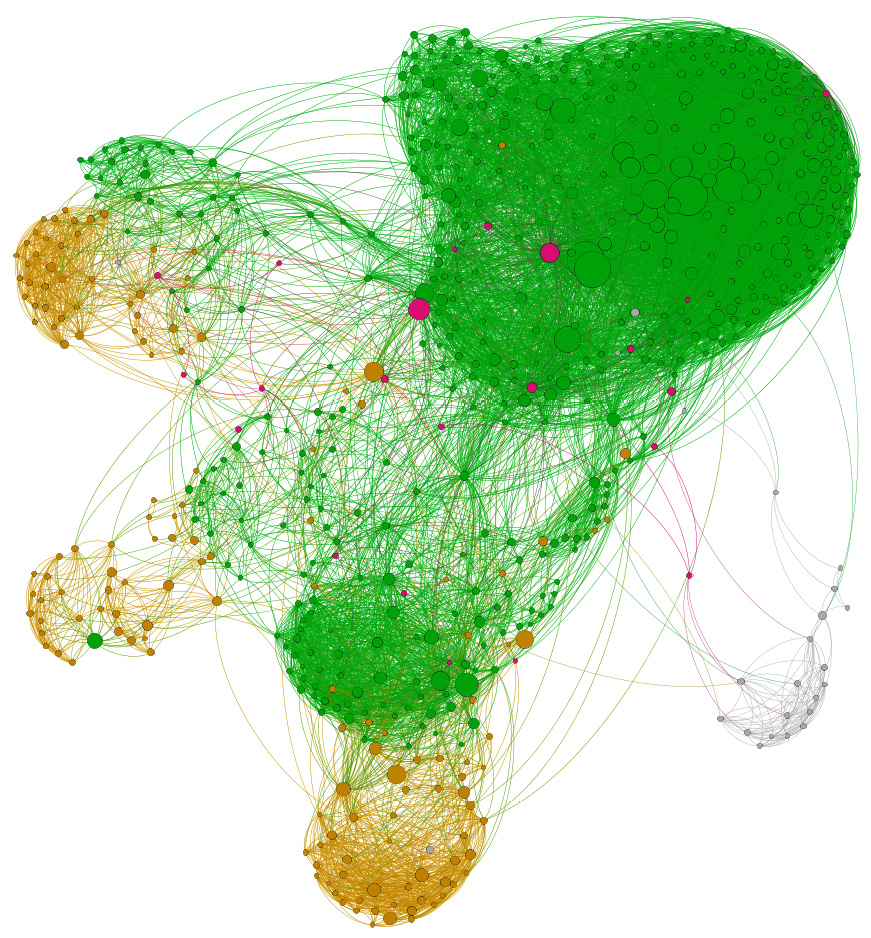

### Load dataset

In [1]:
from torch_geometric.datasets import FacebookPagePage

# Import dataset from PyTorch Geometric
dataset = FacebookPagePage(root=".")

data = dataset[0]

# Print information about the dataset
print(f'Dataset: {dataset}')
print('-----------------------')
print(f'Number of graphs: {len(dataset)}')
print(f'Number of nodes: {data.x.shape[0]}')
print(f'Number of features: {dataset.num_features}')
print(f'Number of classes: {dataset.num_classes}')

# Print information about the graph
print(f'\nGraph:')
print('------')
print(f'Edges are directed: {data.is_directed()}')
print(f'Graph has isolated nodes: {data.has_isolated_nodes()}')
print(f'Graph has loops: {data.has_self_loops()}')

# Create masks
data.train_mask = range(18000)
data.val_mask = range(18001, 20000)
data.test_mask = range(20001, 22470)

Processing...
Done!


Dataset: FacebookPagePage()
-----------------------
Number of graphs: 1
Number of nodes: 22470
Number of features: 128
Number of classes: 4

Graph:
------
Edges are directed: False
Graph has isolated nodes: False
Graph has loops: True


## Visualizing the graph

In [3]:
import matplotlib.pyplot as plt
import networkx as nx
from torch_geometric.utils import to_networkx

# Convertir el grafo a un objeto de NetworkX
G = to_networkx(data, to_undirected=True)

In [ ]:
# Dibuja el grafo usando spring layout
plt.figure(figsize=(10, 10))
pos = nx.spring_layout(G, iterations=15,seed=42)  # Seed para una disposición consistente
nx.draw(G, pos, with_labels=False, node_size=30, node_color="skyblue", edge_color="gray", width=0.5)
plt.show()

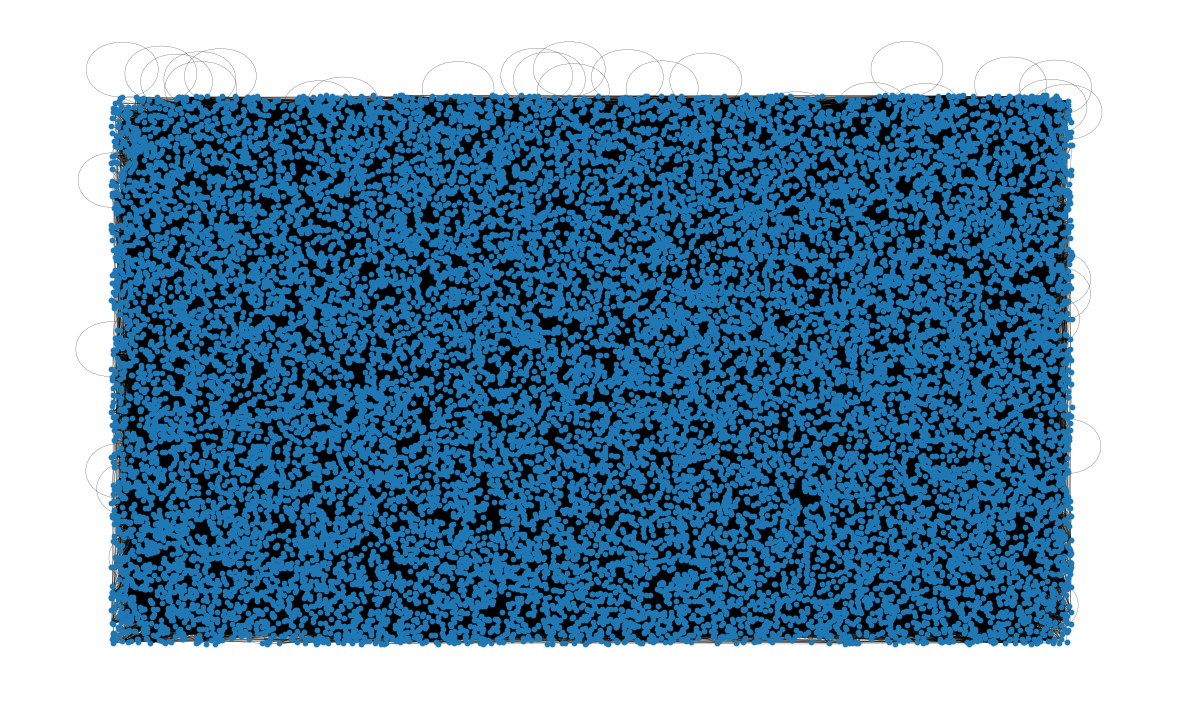

In [ ]:
fig, ax = plt.subplots(figsize=(15, 9))
ax.axis("off")
plot_options = {"node_size": 10, "with_labels": False, "width": 0.15}
nx.draw_networkx(G, pos=nx.random_layout(G), ax=ax, **plot_options)

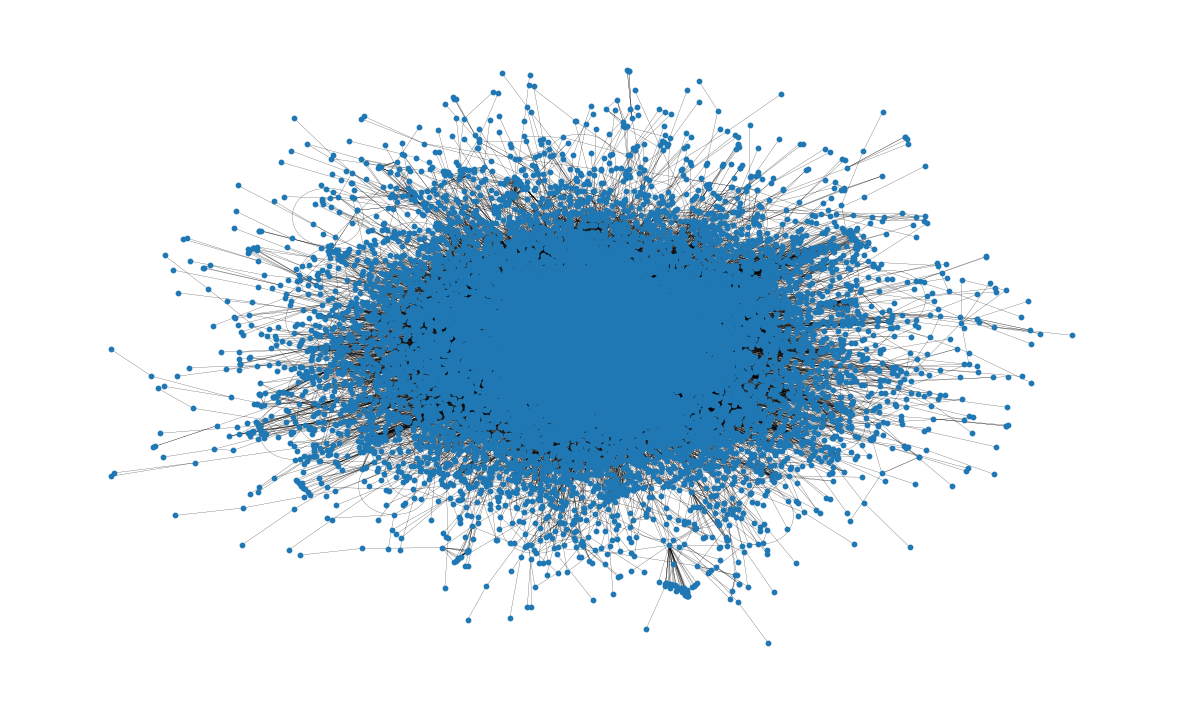

In [ ]:
pos = nx.spring_layout(G, iterations=15, seed=1721)
fig, ax = plt.subplots(figsize=(15, 9))
ax.axis("off")
nx.draw_networkx(G, pos=pos, ax=ax, **plot_options)

In [4]:
# Crear un diccionario de colores basado en las etiquetas de clase
class_colors = {0: 'red', 1: 'blue', 2:'green',3:'black'}
node_colors = [class_colors[int(data.y[node])] for node in range(data.num_nodes)]

# Asignar etiquetas de clase como atributo del nodo
for node in G.nodes:
    G.nodes[node]['class'] = int(data.y[node])

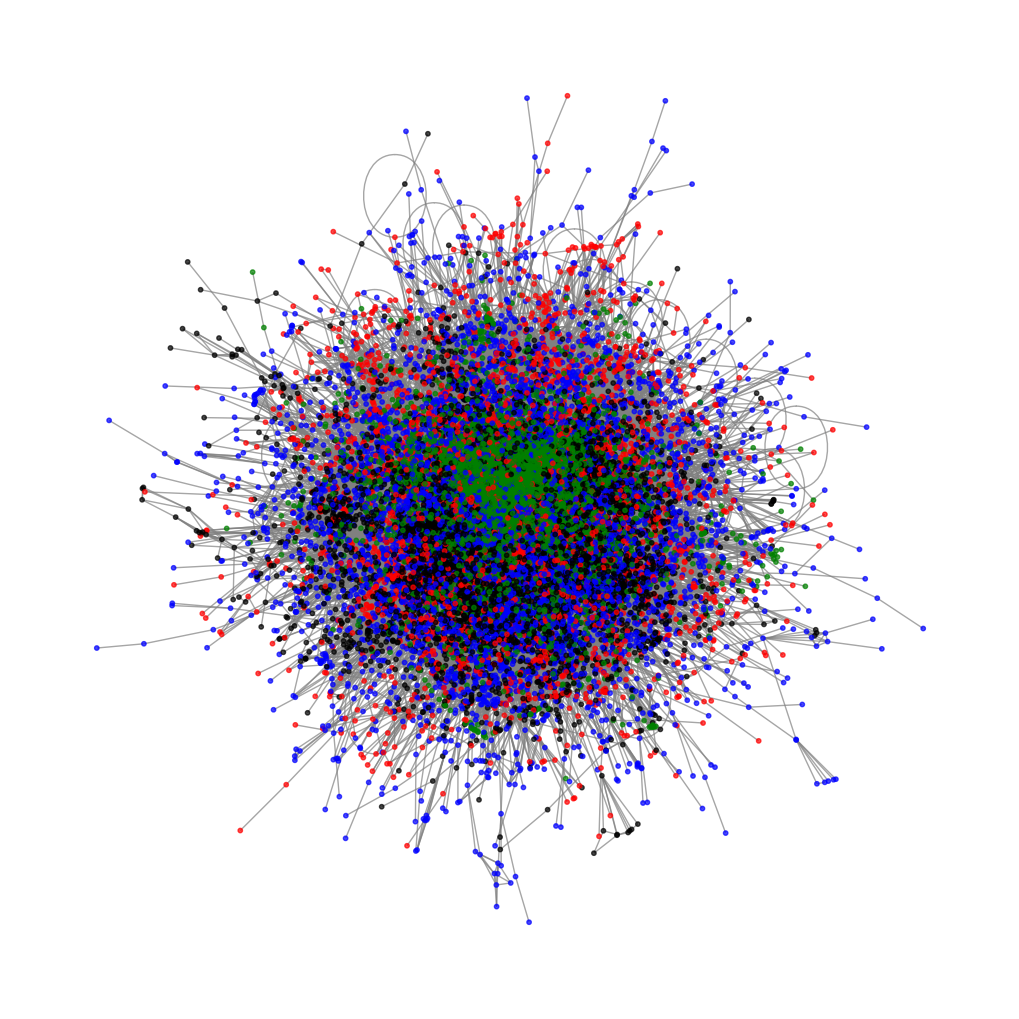

In [ ]:
# Opcional: Visualizar el grafo Demorado
plt.figure(figsize=(10, 10))
pos = nx.spring_layout(G, iterations=15,seed=42)
nx.draw(G, pos, node_color=node_colors, node_size=10, edge_color="gray", alpha=0.7)
plt.show()

### Split dataset

In [5]:
# Dataset
dataset = FacebookPagePage(root=".")
data = dataset[0]
data.train_mask = range(18000)
data.val_mask = range(18001, 20000)
data.test_mask = range(20001, 22470)

### Build Adjacency Matrix

In [6]:
import torch
from torch_geometric.utils import to_dense_adj

# Adjacency matrix
adjacency = to_dense_adj(data.edge_index)[0]
adjacency += torch.eye(len(adjacency))
adjacency

tensor([[1., 0., 0.,  ..., 0., 0., 0.],
        [0., 1., 0.,  ..., 0., 0., 0.],
        [0., 0., 1.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 1., 0., 0.],
        [0., 0., 0.,  ..., 0., 1., 0.],
        [0., 0., 0.,  ..., 0., 0., 1.]])

### Build MLP class

In [23]:
torch.manual_seed(0)
from torch.nn import Linear
import torch.nn.functional as F


def accuracy(y_pred, y_true):
    """Calculate accuracy."""
    return torch.sum(y_pred == y_true) / len(y_true)

In [24]:
class MLP(torch.nn.Module):
    """Multilayer Perceptron"""
    def __init__(self, dim_in, dim_h, dim_out):
        super().__init__()
        self.linear1 = Linear(dim_in, dim_h)
        self.linear2 = Linear(dim_h, dim_out)

    def forward(self, x):
        x = self.linear1(x)
        x = torch.relu(x)
        x = self.linear2(x)
        return F.log_softmax(x, dim=1)

    def fit(self, data, epochs):
        criterion = torch.nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(self.parameters(),
                                          lr=0.01,
                                          weight_decay=5e-4)

        self.train()
        for epoch in range(epochs+1):
            optimizer.zero_grad()
            out = self(data.x)
            loss = criterion(out[data.train_mask], data.y[data.train_mask])
            acc = accuracy(out[data.train_mask].argmax(dim=1),
                          data.y[data.train_mask])
            loss.backward()
            optimizer.step()

            if(epoch % 20 == 0):
                val_loss = criterion(out[data.val_mask], data.y[data.val_mask])
                val_acc = accuracy(out[data.val_mask].argmax(dim=1),
                                  data.y[data.val_mask])
                print(f'Epoch {epoch:>3} | Train Loss: {loss:.3f} | Train Acc:'
                      f' {acc*100:>5.2f}% | Val Loss: {val_loss:.2f} | '
                      f'Val Acc: {val_acc*100:.2f}%')

    @torch.no_grad()
    def test(self, data):
        self.eval()
        out = self(data.x)
        return accuracy(out.argmax(dim=1)[data.test_mask], data.y[data.test_mask])

### Build GNN class

In [25]:
import torch
torch.manual_seed(0)
from torch.nn import Linear
import torch.nn.functional as F


def accuracy(y_pred, y_true):
    """Calculate accuracy."""
    return torch.sum(y_pred == y_true) / len(y_true)

In [26]:
class SparseLayer(torch.nn.Module):
    def __init__(self, dim_in, dim_out):
        super().__init__()
        self.linear = Linear(dim_in, dim_out, bias=False)

    def forward(self, x, adjacency):
        x = self.linear(x)
        x = torch.sparse.mm(adjacency, x)
        return x

In [27]:
class GNN(torch.nn.Module):
    """Vanilla Graph Neural Network"""
    def __init__(self, dim_in, dim_h, dim_out):
        super().__init__()
        self.gnn1 = SparseLayer(dim_in, dim_h)
        self.gnn2 = SparseLayer(dim_h, dim_out)

    def forward(self, x, adjacency):
        h = self.gnn1(x, adjacency)
        h = torch.relu(h)
        h = self.gnn2(h, adjacency)
        return F.log_softmax(h, dim=1)

    def fit(self, data, epochs):
        criterion = torch.nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(self.parameters(),
                                      lr=0.01,
                                      weight_decay=5e-4)

        self.train()
        for epoch in range(epochs+1):
            optimizer.zero_grad()
            out = self(data.x, adjacency)
            loss = criterion(out[data.train_mask], data.y[data.train_mask])
            acc = accuracy(out[data.train_mask].argmax(dim=1),
                          data.y[data.train_mask])
            loss.backward()
            optimizer.step()

            if(epoch % 20 == 0):
                val_loss = criterion(out[data.val_mask], data.y[data.val_mask])
                val_acc = accuracy(out[data.val_mask].argmax(dim=1),
                                  data.y[data.val_mask])
                print(f'Epoch {epoch:>3} | Train Loss: {loss:.3f} | Train Acc:'
                      f' {acc*100:>5.2f}% | Val Loss: {val_loss:.2f} | '
                      f'Val Acc: {val_acc*100:.2f}%')

    @torch.no_grad()
    def test(self, data):
        self.eval()
        out = self(data.x, adjacency)
        acc = accuracy(out.argmax(dim=1)[data.test_mask], data.y[data.test_mask])
        return acc

### Run models and compare

In [28]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [14]:
# MLP
mlp = MLP(dataset.num_features, 16, dataset.num_classes)
print(mlp)
mlp.fit(data, epochs=100)
acc = mlp.test(data)
print(f'\nMLP test accuracy: {acc*100:.2f}%\n')

# GCN
gnn = GNN(dataset.num_features, 16, dataset.num_classes)
print(gnn)
gnn.fit(data, epochs=100)
acc = gnn.test(data)
print(f'\nGNN test accuracy: {acc*100:.2f}%')

MLP(
  (linear1): Linear(in_features=128, out_features=16, bias=True)
  (linear2): Linear(in_features=16, out_features=4, bias=True)
)
Epoch   0 | Train Loss: 1.374 | Train Acc: 28.21% | Val Loss: 1.38 | Val Acc: 26.61%
Epoch  20 | Train Loss: 0.641 | Train Acc: 74.46% | Val Loss: 0.67 | Val Acc: 71.84%
Epoch  40 | Train Loss: 0.566 | Train Acc: 77.31% | Val Loss: 0.61 | Val Acc: 75.24%
Epoch  60 | Train Loss: 0.542 | Train Acc: 78.38% | Val Loss: 0.60 | Val Acc: 75.39%
Epoch  80 | Train Loss: 0.527 | Train Acc: 79.14% | Val Loss: 0.60 | Val Acc: 75.69%
Epoch 100 | Train Loss: 0.514 | Train Acc: 79.68% | Val Loss: 0.60 | Val Acc: 75.69%

MLP test accuracy: 75.09%

GNN(
  (gnn1): SparseLayer(
    (linear): Linear(in_features=128, out_features=16, bias=False)
  )
  (gnn2): SparseLayer(
    (linear): Linear(in_features=16, out_features=4, bias=False)
  )
)
Epoch   0 | Train Loss: 58.291 | Train Acc: 27.83% | Val Loss: 57.57 | Val Acc: 28.26%
Epoch  20 | Train Loss: 5.829 | Train Acc: 80.0

## Split dataset
User a pytorch random split and debug model classes...

In [20]:
## Codigo que venía en el taller

# Example with random_split
#train_size = int(0.8 * len(full_dataset))
#test_size = len(full_dataset) - train_size
#train_dataset, test_dataset = torch.utils.data.random_split(full_dataset, [train_size, test_size])

## Codigo ajustado

# Example with random_split
import torch
from torch.utils.data import random_split

# Número total de nodos en el grafo
num_nodes = data.x.shape[0]

# Crear una lista con índices de nodos
all_indices = list(range(num_nodes))

# Definir los tamaños de cada subconjunto
train_size = int(0.8 * num_nodes)
val_size = int(0.1 * num_nodes)
test_size = num_nodes - train_size - val_size

# Dividir los índices de los nodos utilizando random_split
train_indices, val_indices, test_indices = random_split(all_indices, [train_size, val_size, test_size])

# Crear las máscaras usando los índices generados
data.train_mask = torch.zeros(num_nodes, dtype=torch.bool)
data.val_mask = torch.zeros(num_nodes, dtype=torch.bool)
data.test_mask = torch.zeros(num_nodes, dtype=torch.bool)

data.train_mask[train_indices] = True
data.val_mask[val_indices] = True
data.test_mask[test_indices] = True

# Verificar la distribución
print(f'Train nodes: {data.train_mask.sum().item()}')
print(f'Validation nodes: {data.val_mask.sum().item()}')
print(f'Test nodes: {data.test_mask.sum().item()}')


Train nodes: 17976
Validation nodes: 2247
Test nodes: 2247


### Build MLP class

### Build GNN class

Teniendo en cuenta que la partición de los datos ya se hizo de forma aleatoria en actualizando las máscaras de data.train_mask , data.val_mask, data.test_mask, se re usan las mismas clases creadas al inicio del notebook

### Run and compare models

In [29]:
# MLP
mlp = MLP(dataset.num_features, 16, dataset.num_classes)
print(mlp)
mlp.fit(data, epochs=100)
acc = mlp.test(data)
print(f'\nMLP test accuracy: {acc*100:.2f}%\n')

# GCN
gnn = GNN(dataset.num_features, 16, dataset.num_classes)
print(gnn)
gnn.fit(data, epochs=100)
acc = gnn.test(data)
print(f'\nGNN test accuracy: {acc*100:.2f}%')

MLP(
  (linear1): Linear(in_features=128, out_features=16, bias=True)
  (linear2): Linear(in_features=16, out_features=4, bias=True)
)
Epoch   0 | Train Loss: 1.465 | Train Acc: 17.50% | Val Loss: 1.48 | Val Acc: 17.53%
Epoch  20 | Train Loss: 0.676 | Train Acc: 73.12% | Val Loss: 0.69 | Val Acc: 72.67%
Epoch  40 | Train Loss: 0.584 | Train Acc: 76.82% | Val Loss: 0.62 | Val Acc: 75.17%
Epoch  60 | Train Loss: 0.556 | Train Acc: 77.83% | Val Loss: 0.61 | Val Acc: 75.34%
Epoch  80 | Train Loss: 0.541 | Train Acc: 78.31% | Val Loss: 0.60 | Val Acc: 75.52%
Epoch 100 | Train Loss: 0.529 | Train Acc: 78.94% | Val Loss: 0.60 | Val Acc: 75.34%

MLP test accuracy: 75.43%

GNN(
  (gnn1): SparseLayer(
    (linear): Linear(in_features=128, out_features=16, bias=False)
  )
  (gnn2): SparseLayer(
    (linear): Linear(in_features=16, out_features=4, bias=False)
  )
)
Epoch   0 | Train Loss: 52.042 | Train Acc: 26.88% | Val Loss: 53.55 | Val Acc: 27.10%
Epoch  20 | Train Loss: 3.225 | Train Acc: 79.7